# **AI 600 Deep Learning Assignment 2**

In [37]:
from google.colab import drive
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

In [38]:
VAL_SIZE = 128
TRAIN_SIZE = 128
TEST_SIZE = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
EPOCHS = 40
PANCAKE_LAYERS = [1024, 1024]
TOWER_LAYERS = [256, 256, 256, 256, 256, 256]
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params


Using device: cuda


In [3]:
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [39]:
with np.load('/content/drive/MyDrive/AI600Assignment2/quickdraw_train.npz') as data:
  X = data['x_train'].astype(np.float32)
  Y = data['y_train']
  class_names = data['class_names']
with np.load('/content/drive/MyDrive/AI600Assignment2/quickdraw_test.npz') as data:
  X_test = data['test_images']

In [40]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape, X_test.shape   

((60000, 784), (15000, 784))

In [41]:
X_train, X_val, Y_train, Y_val = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

X_train_tensor = torch.from_numpy(X_train)
Y_train_tensor = torch.from_numpy(Y_train).long()
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=TRAIN_SIZE, shuffle=True)

X_val_tensor = torch.from_numpy(X_val)
Y_val_tensor = torch.from_numpy(Y_val).long()
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(dataset=val_dataset, batch_size=VAL_SIZE, shuffle=False)

X_test_float = X_test.astype(np.float32)
X_test_scaled = scaler.transform(X_test_float)
X_test_tensor = torch.from_numpy(X_test_scaled)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(dataset=test_dataset, batch_size=TEST_SIZE, shuffle=False)


In [42]:
class Pancake(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=PANCAKE_LAYERS):
    super(Pancake, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.ReLU())
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)


In [43]:
model = Pancake().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [44]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_pancake.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.1163 | Train Acc: 63.52%
Val Loss:   0.8869 | Val Acc:   70.49%
------------------------------
Epoch 2/40
Train Loss: 0.7954 | Train Acc: 73.91%
Val Loss:   0.7977 | Val Acc:   74.33%
------------------------------
Epoch 3/40
Train Loss: 0.6484 | Train Acc: 78.35%
Val Loss:   0.7660 | Val Acc:   75.29%
------------------------------
Epoch 4/40
Train Loss: 0.5337 | Train Acc: 81.96%
Val Loss:   0.7464 | Val Acc:   76.27%
------------------------------
Epoch 5/40
Train Loss: 0.4363 | Train Acc: 85.08%
Val Loss:   0.7776 | Val Acc:   76.24%
------------------------------
Epoch 6/40
Train Loss: 0.3515 | Train Acc: 87.77%
Val Loss:   0.8284 | Val Acc:   76.39%
------------------------------
Epoch 7/40
Train Loss: 0.2783 | Train Acc: 90.21%
Val Loss:   0.8721 | Val Acc:   75.83%
------------------------------
Epoch 8/40
Train Loss: 0.2181 | Train Acc: 92.24%
Val Loss:   0.9756 | Val Acc:   75.89%
------------------------------
Epoch 9/40
Train Loss: 0.1705 | Train Ac

In [45]:
count_parameters(model)

1868815

In [46]:
class Tower(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=TOWER_LAYERS):
    super(Tower, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.ReLU())
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)


  def forward(self, x):
      return self.network(x)


In [ ]:
model = Tower().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [48]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_tower.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.4016 | Train Acc: 51.28%
Val Loss:   1.0999 | Val Acc:   63.14%
------------------------------
Epoch 2/40
Train Loss: 0.9757 | Train Acc: 67.25%
Val Loss:   0.9364 | Val Acc:   68.35%
------------------------------
Epoch 3/40
Train Loss: 0.8426 | Train Acc: 71.80%
Val Loss:   0.8769 | Val Acc:   70.58%
------------------------------
Epoch 4/40
Train Loss: 0.7545 | Train Acc: 74.50%
Val Loss:   0.8360 | Val Acc:   72.32%
------------------------------
Epoch 5/40
Train Loss: 0.6903 | Train Acc: 76.76%
Val Loss:   0.8347 | Val Acc:   73.01%
------------------------------
Epoch 6/40
Train Loss: 0.6347 | Train Acc: 78.76%
Val Loss:   0.8136 | Val Acc:   73.78%
------------------------------
Epoch 7/40
Train Loss: 0.5847 | Train Acc: 80.19%
Val Loss:   0.8178 | Val Acc:   74.08%
------------------------------
Epoch 8/40
Train Loss: 0.5416 | Train Acc: 81.75%
Val Loss:   0.8377 | Val Acc:   74.08%
------------------------------
Epoch 9/40
Train Loss: 0.4988 | Train Ac

In [49]:
count_parameters(model)

533775

In [50]:
CHAMPION_LAYERS = [512, 256, 128]

In [65]:
class Champion(nn.Module):
  def __init__(self, input_size=784, num_classes=15, hidden_layers=CHAMPION_LAYERS):
    super(Champion, self).__init__()
    layers = [nn.Flatten()]
    current_dim = input_size
    for h_dim in hidden_layers:
        layers.append(nn.Linear(current_dim, h_dim))
        layers.append(nn.BatchNorm1d(h_dim))
        # layers.append(nn.ReLU()) Iteration 4 removal
        layers.append(nn.GELU()) # Iteration 4 addition
        layers.append(nn.Dropout(0.4))
        current_dim = h_dim
    layers.append(nn.Linear(current_dim, num_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [52]:
# First train the champion model with the same training loop as before, then evaluate on the validation set.
# CHAMPION_LAYERS = [512, 256, 128] for first iteration, no changes other than that.
model = Champion().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [53]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion1.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.2527 | Train Acc: 58.49%
Val Loss:   0.9834 | Val Acc:   67.44%
------------------------------
Epoch 2/40
Train Loss: 0.8878 | Train Acc: 70.75%
Val Loss:   0.8624 | Val Acc:   71.27%
------------------------------
Epoch 3/40
Train Loss: 0.7542 | Train Acc: 75.08%
Val Loss:   0.8033 | Val Acc:   73.84%
------------------------------
Epoch 4/40
Train Loss: 0.6544 | Train Acc: 78.38%
Val Loss:   0.7575 | Val Acc:   75.38%
------------------------------
Epoch 5/40
Train Loss: 0.5710 | Train Acc: 80.83%
Val Loss:   0.7718 | Val Acc:   75.25%
------------------------------
Epoch 6/40
Train Loss: 0.4984 | Train Acc: 83.09%
Val Loss:   0.7773 | Val Acc:   75.56%
------------------------------
Epoch 7/40
Train Loss: 0.4372 | Train Acc: 85.08%
Val Loss:   0.7854 | Val Acc:   75.54%
------------------------------
Epoch 8/40
Train Loss: 0.3767 | Train Acc: 87.00%
Val Loss:   0.8242 | Val Acc:   75.63%
------------------------------
Epoch 9/40
Train Loss: 0.3219 | Train Ac

In [54]:
# Modify the champion model architecture and/or training procedure to improve validation accuracy.
# First changing the optimizer to AdamW, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [55]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion2.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.2674 | Train Acc: 58.56%
Val Loss:   0.9721 | Val Acc:   68.06%
------------------------------
Epoch 2/40
Train Loss: 0.9028 | Train Acc: 70.34%
Val Loss:   0.8800 | Val Acc:   70.97%
------------------------------
Epoch 3/40
Train Loss: 0.7733 | Train Acc: 74.61%
Val Loss:   0.8070 | Val Acc:   73.66%
------------------------------
Epoch 4/40
Train Loss: 0.6678 | Train Acc: 77.90%
Val Loss:   0.7810 | Val Acc:   74.31%
------------------------------
Epoch 5/40
Train Loss: 0.5837 | Train Acc: 80.50%
Val Loss:   0.7733 | Val Acc:   75.56%
------------------------------
Epoch 6/40
Train Loss: 0.5140 | Train Acc: 82.76%
Val Loss:   0.8073 | Val Acc:   74.71%
------------------------------
Epoch 7/40
Train Loss: 0.4515 | Train Acc: 84.64%
Val Loss:   0.7707 | Val Acc:   76.31%
------------------------------
Epoch 8/40
Train Loss: 0.3921 | Train Acc: 86.65%
Val Loss:   0.8110 | Val Acc:   76.45%
------------------------------
Epoch 9/40
Train Loss: 0.3415 | Train Ac

In [56]:
count_parameters(model)

568079

In [60]:
# Added Batch Normalization, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [61]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion3.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.0179 | Train Acc: 66.94%
Val Loss:   0.8072 | Val Acc:   72.97%
------------------------------
Epoch 2/40
Train Loss: 0.7313 | Train Acc: 75.65%
Val Loss:   0.7443 | Val Acc:   74.92%
------------------------------
Epoch 3/40
Train Loss: 0.6017 | Train Acc: 79.84%
Val Loss:   0.7239 | Val Acc:   76.02%
------------------------------
Epoch 4/40
Train Loss: 0.5116 | Train Acc: 82.80%
Val Loss:   0.6947 | Val Acc:   77.43%
------------------------------
Epoch 5/40
Train Loss: 0.4280 | Train Acc: 85.53%
Val Loss:   0.7310 | Val Acc:   77.31%
------------------------------
Epoch 6/40
Train Loss: 0.3613 | Train Acc: 87.66%
Val Loss:   0.7473 | Val Acc:   77.99%
------------------------------
Epoch 7/40
Train Loss: 0.2963 | Train Acc: 89.71%
Val Loss:   0.7947 | Val Acc:   77.14%
------------------------------
Epoch 8/40
Train Loss: 0.2424 | Train Acc: 91.77%
Val Loss:   0.8374 | Val Acc:   76.57%
------------------------------
Epoch 9/40
Train Loss: 0.2012 | Train Ac

In [63]:
# Added Dropout p=0.4, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [64]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion4.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.3190 | Train Acc: 57.65%
Val Loss:   0.9260 | Val Acc:   69.38%
------------------------------
Epoch 2/40
Train Loss: 1.0145 | Train Acc: 66.55%
Val Loss:   0.8369 | Val Acc:   71.97%
------------------------------
Epoch 3/40
Train Loss: 0.9311 | Train Acc: 69.27%
Val Loss:   0.7876 | Val Acc:   73.62%
------------------------------
Epoch 4/40
Train Loss: 0.8767 | Train Acc: 71.03%
Val Loss:   0.7658 | Val Acc:   74.18%
------------------------------
Epoch 5/40
Train Loss: 0.8292 | Train Acc: 72.59%
Val Loss:   0.7377 | Val Acc:   75.30%
------------------------------
Epoch 6/40
Train Loss: 0.7965 | Train Acc: 73.77%
Val Loss:   0.7183 | Val Acc:   76.07%
------------------------------
Epoch 7/40
Train Loss: 0.7636 | Train Acc: 74.59%
Val Loss:   0.7059 | Val Acc:   76.55%
------------------------------
Epoch 8/40
Train Loss: 0.7338 | Train Acc: 75.68%
Val Loss:   0.6953 | Val Acc:   77.21%
------------------------------
Epoch 9/40
Train Loss: 0.7080 | Train Ac

In [66]:
# Added GeLu(), then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [67]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion5.pth')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Epoch 1/40
Train Loss: 1.2580 | Train Acc: 59.29%
Val Loss:   0.8936 | Val Acc:   70.28%
------------------------------
Epoch 2/40
Train Loss: 0.9641 | Train Acc: 68.21%
Val Loss:   0.8097 | Val Acc:   72.59%
------------------------------
Epoch 3/40
Train Loss: 0.8749 | Train Acc: 71.01%
Val Loss:   0.7598 | Val Acc:   74.58%
------------------------------
Epoch 4/40
Train Loss: 0.8107 | Train Acc: 73.12%
Val Loss:   0.7273 | Val Acc:   75.92%
------------------------------
Epoch 5/40
Train Loss: 0.7600 | Train Acc: 74.93%
Val Loss:   0.7068 | Val Acc:   76.47%
------------------------------
Epoch 6/40
Train Loss: 0.7204 | Train Acc: 76.19%
Val Loss:   0.6828 | Val Acc:   77.48%
------------------------------
Epoch 7/40
Train Loss: 0.6891 | Train Acc: 77.15%
Val Loss:   0.6730 | Val Acc:   77.53%
------------------------------
Epoch 8/40
Train Loss: 0.6508 | Train Acc: 78.36%
Val Loss:   0.6673 | Val Acc:   78.10%
------------------------------
Epoch 9/40
Train Loss: 0.6257 | Train Ac

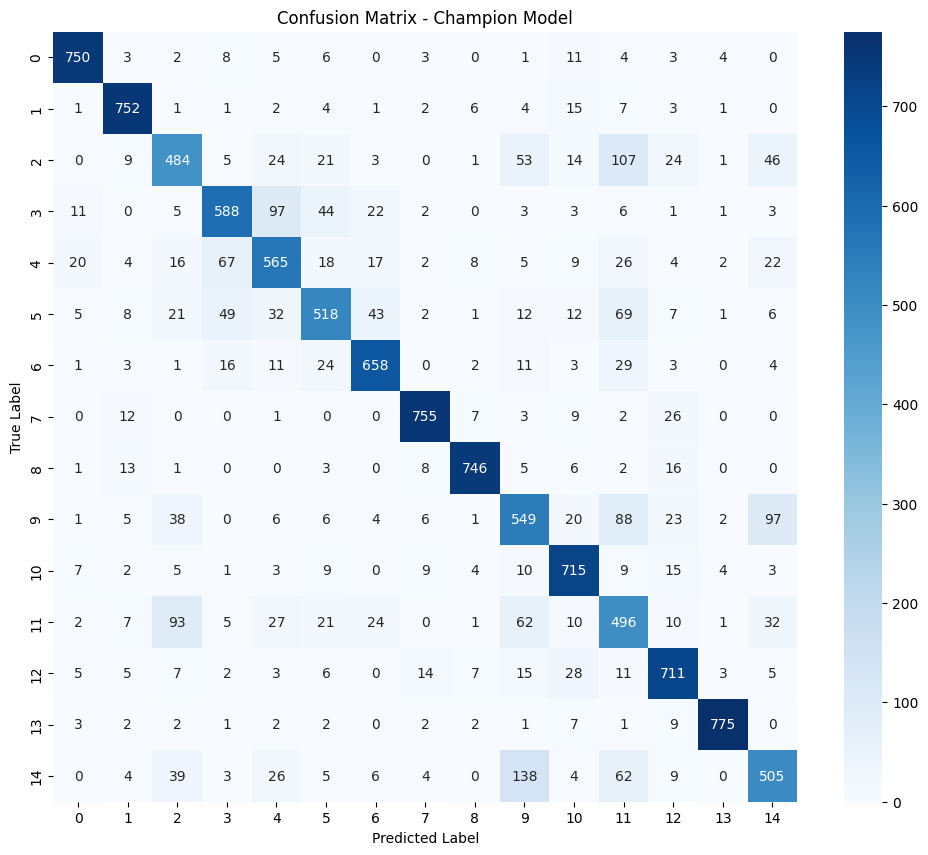

Top 2 Most Confused Pairs:
True Class 14 was predicted as Class 9 -> 138 times
True Class 2 was predicted as Class 11 -> 107 times


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 1. Load your best saved weights into the Champion model
model = Champion() # Ensure your CHAMPION_LAYERS are [512, 256, 128]
model.load_state_dict(torch.load('best_model_champion4.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

# 2. Gather all predictions from the validation set
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Champion Model')
plt.show()

# 4. Find the Top 2 Confused Pairs
# Fill diagonal with 0s so we only look at mistakes
np.fill_diagonal(cm, 0)

# Flatten and get the indices of the highest errors
flat_cm = cm.flatten()
top_2_indices = flat_cm.argsort()[-2:][::-1]

print("Top 2 Most Confused Pairs:")
for idx in top_2_indices:
    true_class = idx // 15  # Assuming 15 classes
    pred_class = idx % 15
    mistakes = cm[true_class, pred_class]
    print(f"True Class {true_class} was predicted as Class {pred_class} -> {mistakes} times")

In [70]:
# Added LR Scheduler, then will experiment with other changes if needed.
model = Champion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

In [71]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train

    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_accuracy = val_correct / val_total if val_total > 0 else 0
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_champion6.pth')
    val_loss_avg = val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
    
    scheduler.step(val_loss_avg)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_accuracy*100:.2f}%")
    print("-" * 30)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Current Learning Rate: 0.001
Epoch 1/40
Train Loss: 1.2583 | Train Acc: 59.42%
Val Loss:   0.8938 | Val Acc:   69.58%
------------------------------
Current Learning Rate: 0.001
Epoch 2/40
Train Loss: 0.9663 | Train Acc: 68.03%
Val Loss:   0.8034 | Val Acc:   72.82%
------------------------------
Current Learning Rate: 0.001
Epoch 3/40
Train Loss: 0.8766 | Train Acc: 71.04%
Val Loss:   0.7586 | Val Acc:   74.27%
------------------------------
Current Learning Rate: 0.001
Epoch 4/40
Train Loss: 0.8137 | Train Acc: 73.04%
Val Loss:   0.7335 | Val Acc:   75.58%
------------------------------
Current Learning Rate: 0.001
Epoch 5/40
Train Loss: 0.7617 | Train Acc: 74.84%
Val Loss:   0.7043 | Val Acc:   76.53%
------------------------------
Current Learning Rate: 0.001
Epoch 6/40
Train Loss: 0.7159 | Train Acc: 76.30%
Val Loss:   0.6976 | Val Acc:   77.10%
------------------------------
Current Learning Rate: 0.001
Epoch 7/40
Train Loss: 0.6832 | Train Acc: 77.21%
Val Loss:   0.6741 | Val Ac